In [1]:
import pandas as pd

block = pd.read_csv("block_21.csv")
user_df = block[block["LCLid"] == "MAC000150"].copy()

half_hour_cols = [f"hh_{i}" for i in range(48)]
df_long = user_df.melt(
    id_vars=["LCLid", "day"],
    value_vars=half_hour_cols,
    var_name="half_hour",
    value_name="energy_kwh"
)

df_long["day"] = pd.to_datetime(df_long["day"])
df_long["half_hour"] = df_long["half_hour"].str.extract("(\d+)").astype(int)
df_long["timestamp"] = df_long["day"] + pd.to_timedelta(df_long["half_hour"] * 30, unit="m")
df_long = df_long.dropna(subset=["energy_kwh"])
df_long.set_index("timestamp", inplace=True)
df_long = df_long.sort_index()


In [2]:

ts_hourly = df_long["energy_kwh"].resample("H").mean().dropna()
ts_daily = df_long["energy_kwh"].resample("D").mean().dropna()
ts_weekly = df_long["energy_kwh"].resample("W").mean().dropna()
ts_monthly = df_long["energy_kwh"].resample("M").mean().dropna()

df_hourly = ts_hourly.reset_index().rename(columns={"timestamp": "ds", "energy_kwh": "y"})
df_daily = ts_daily.reset_index().rename(columns={"timestamp": "ds", "energy_kwh": "y"})
df_weekly = ts_weekly.reset_index().rename(columns={"timestamp": "ds", "energy_kwh": "y"})
df_monthly = ts_monthly.reset_index().rename(columns={"timestamp": "ds", "energy_kwh": "y"})

df_hourly.head()


/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_24522/3148776245.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_hourly = df_long["energy_kwh"].resample("H").mean().dropna()
/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_24522/3148776245.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_monthly = df_long["energy_kwh"].resample("M").mean().dropna()


,ds,y
0,2011-11-24 00:00:00,0.1810
1,2011-11-24 01:00:00,0.1535
2,2011-11-24 02:00:00,0.1500
3,2011-11-24 03:00:00,0.1155
4,2011-11-24 04:00:00,0.0755


In [3]:
def add_lag_features(df, lags=[1, 2, 3]):
    """
    Adds lag features to the DataFrame.

    Parameters:
        df: DataFrame with 'y' and 'ds'
        lags: list of lag steps to include

    Returns:
        DataFrame with new lag columns
    """
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    return df


In [6]:
def add_temporal_features(df, freq):
    """
    Adds frequency-appropriate temporal features to a time series DataFrame.

    Parameters:
        df: DataFrame with 'ds' datetime column
        freq: 'H', 'D', 'W', or 'M'

    Returns:
        DataFrame with additional time-based features
    """
    df = df.copy()
    if freq == 'H':
        df['hour'] = df['ds'].dt.hour
        df['dayofweek'] = df['ds'].dt.dayofweek
        df['month'] = df['ds'].dt.month

    elif freq == 'D':
        df['dayofweek'] = df['ds'].dt.dayofweek
        df['month'] = df['ds'].dt.month

    elif freq == 'W':
        df['weekofyear'] = df['ds'].dt.isocalendar().week.astype(int)
        df['month'] = df['ds'].dt.month

    elif freq == 'M':
        df['month'] = df['ds'].dt.month

    else:
        raise ValueError(f"Unsupported frequency: {freq}")

    return df


In [5]:
def prepare_features(df, lags=None, temporal=False, freq='H'):
    """
    Adds lag and/or temporal features to a time series DataFrame.

    Parameters:
        df: DataFrame with 'ds' and 'y'
        lags: list of lag steps (e.g., [1,2,3]); None = no lag features
        temporal: whether to add temporal features
        freq: time resolution (H, D, W, M)

    Returns:
        Feature-enriched DataFrame
    """
    df = df.copy()
    if lags:
        df = add_lag_features(df, lags)
    if temporal:
        df = add_temporal_features(df, freq)
    df = df.dropna()
    return df


In [7]:
def train_test_split(df, test_size):
    """
    Splits time series dataframe into train and test sets.

    Parameters:
        df: DataFrame with features (must include 'y')
        test_size: number of recent samples to use for testing

    Returns:
        X_train, X_test, y_train, y_test
    """
    df = df.dropna().copy()
    X = df.drop(columns=['y', 'ds'])
    y = df['y']

    X_train = X.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_train = y.iloc[:-test_size]
    y_test = y.iloc[-test_size:]

    return X_train, X_test, y_train, y_test


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare features
df_daily_features = prepare_features(df_daily, lags=[1,2,3], temporal=True, freq='D')

# Split
X_train, X_test, y_train, y_test = train_test_split(df_daily_features, test_size=30)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")


MAE: 0.0622, RMSE: 0.0819


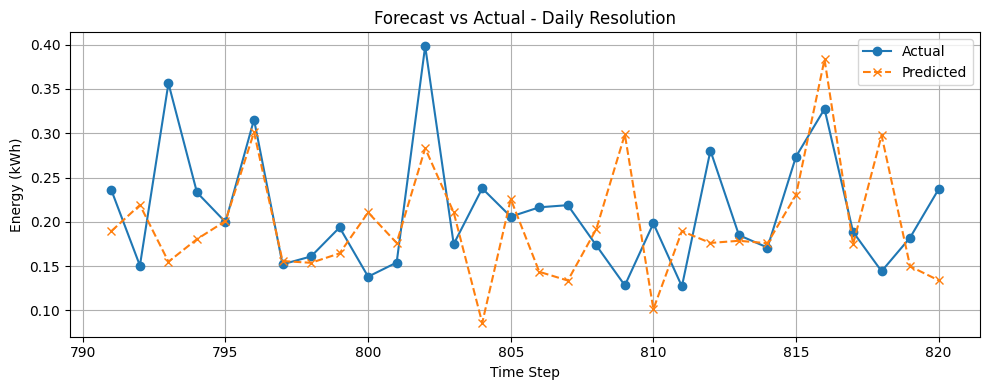

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--', marker='x')
plt.title('Forecast vs Actual - Daily Resolution')
plt.xlabel('Time Step')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
df_hourly_lag = prepare_features(df_hourly, lags=[1, 2, 3], temporal=False, freq='H')
X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(df_hourly_lag, test_size=168)

model_lag = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_lag.fit(X_train_lag, y_train_lag)
y_pred_lag = model_lag.predict(X_test_lag)


In [12]:
df_hourly_temp = prepare_features(df_hourly, lags=None, temporal=True, freq='H')
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(df_hourly_temp, test_size=168)

model_temp = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_temp.fit(X_train_temp, y_train_temp)
y_pred_temp = model_temp.predict(X_test_temp)


In [13]:
df_hourly_comb = prepare_features(df_hourly, lags=[1, 2, 3], temporal=True, freq='H')
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(df_hourly_comb, test_size=168)

model_comb = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_comb.fit(X_train_comb, y_train_comb)
y_pred_comb = model_comb.predict(X_test_comb)


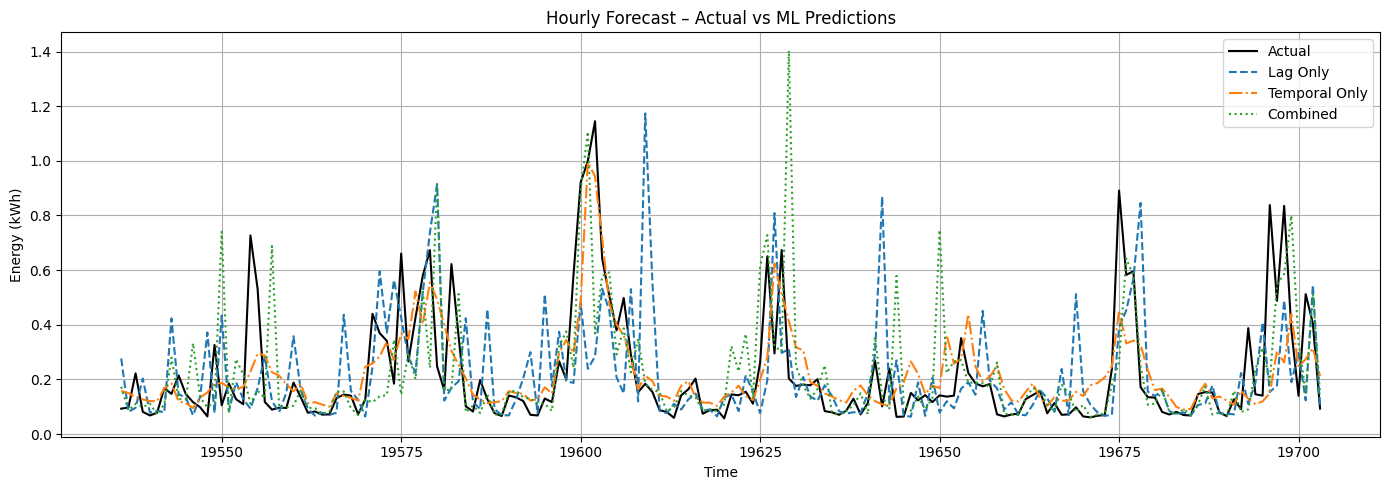

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(y_test_comb.index, y_test_comb.values, label='Actual', color='black')
plt.plot(y_test_lag.index, y_pred_lag, label='Lag Only', linestyle='--')
plt.plot(y_test_temp.index, y_pred_temp, label='Temporal Only', linestyle='-.')
plt.plot(y_test_comb.index, y_pred_comb, label='Combined', linestyle='dotted')

plt.title('Hourly Forecast – Actual vs ML Predictions')
plt.xlabel('Time')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:


mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)
rmse_lag = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))

mae_temp = mean_absolute_error(y_test_temp, y_pred_temp)
rmse_temp = np.sqrt(mean_squared_error(y_test_temp, y_pred_temp))

mae_comb = mean_absolute_error(y_test_comb, y_pred_comb)
rmse_comb = np.sqrt(mean_squared_error(y_test_comb, y_pred_comb))

print(f"[Hourly | Lag Only]      MAE: {mae_lag:.4f}, RMSE: {rmse_lag:.4f}")
print(f"[Hourly | Temporal Only] MAE: {mae_temp:.4f}, RMSE: {rmse_temp:.4f}")
print(f"[Hourly | Combined]      MAE: {mae_comb:.4f}, RMSE: {rmse_comb:.4f}")


[Hourly | Lag Only]      MAE: 0.1422, RMSE: 0.2342
[Hourly | Temporal Only] MAE: 0.0942, RMSE: 0.1424
[Hourly | Combined]      MAE: 0.1159, RMSE: 0.2149


In [16]:
df_daily_lag = prepare_features(df_daily, lags=[1, 2, 3], temporal=False, freq='D')
X_train_lag_d, X_test_lag_d, y_train_lag_d, y_test_lag_d = train_test_split(df_daily_lag, test_size=30)

model_lag_d = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_lag_d.fit(X_train_lag_d, y_train_lag_d)
y_pred_lag_d = model_lag_d.predict(X_test_lag_d)


In [17]:
df_daily_temp = prepare_features(df_daily, lags=None, temporal=True, freq='D')
X_train_temp_d, X_test_temp_d, y_train_temp_d, y_test_temp_d = train_test_split(df_daily_temp, test_size=30)

model_temp_d = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_temp_d.fit(X_train_temp_d, y_train_temp_d)
y_pred_temp_d = model_temp_d.predict(X_test_temp_d)


In [18]:
df_daily_comb = prepare_features(df_daily, lags=[1, 2, 3], temporal=True, freq='D')
X_train_comb_d, X_test_comb_d, y_train_comb_d, y_test_comb_d = train_test_split(df_daily_comb, test_size=30)

model_comb_d = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_comb_d.fit(X_train_comb_d, y_train_comb_d)
y_pred_comb_d = model_comb_d.predict(X_test_comb_d)


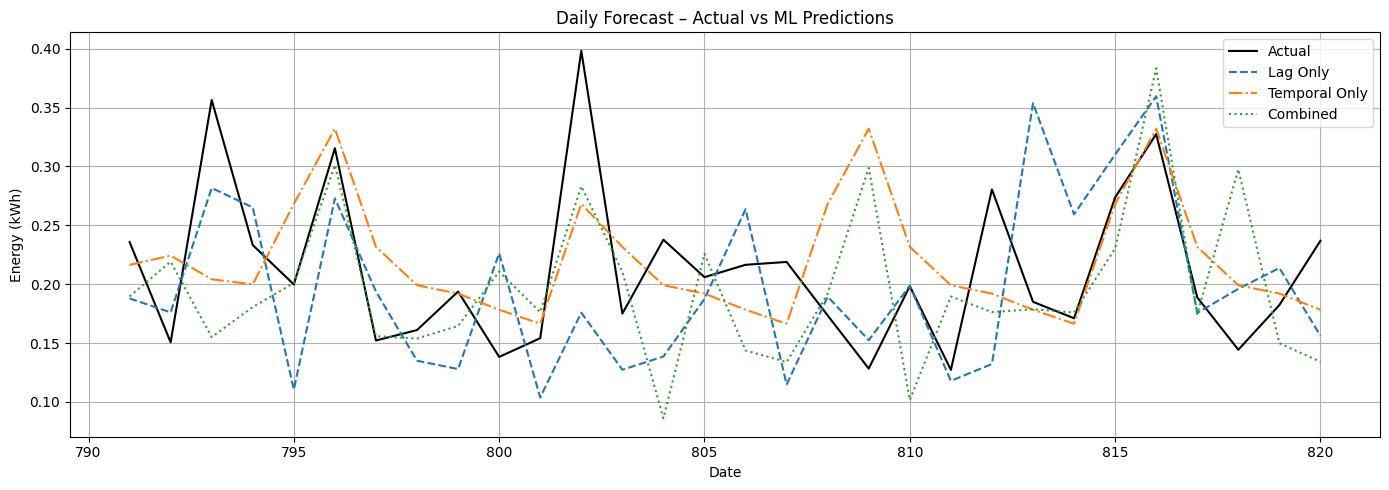

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(y_test_comb_d.index, y_test_comb_d.values, label='Actual', color='black')
plt.plot(y_test_lag_d.index, y_pred_lag_d, label='Lag Only', linestyle='--')
plt.plot(y_test_temp_d.index, y_pred_temp_d, label='Temporal Only', linestyle='-.')
plt.plot(y_test_comb_d.index, y_pred_comb_d, label='Combined', linestyle='dotted')

plt.title('Daily Forecast – Actual vs ML Predictions')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
mae_lag_d = mean_absolute_error(y_test_lag_d, y_pred_lag_d)
rmse_lag_d = np.sqrt(mean_squared_error(y_test_lag_d, y_pred_lag_d))

mae_temp_d = mean_absolute_error(y_test_temp_d, y_pred_temp_d)
rmse_temp_d = np.sqrt(mean_squared_error(y_test_temp_d, y_pred_temp_d))

mae_comb_d = mean_absolute_error(y_test_comb_d, y_pred_comb_d)
rmse_comb_d = np.sqrt(mean_squared_error(y_test_comb_d, y_pred_comb_d))

print(f"[Daily | Lag Only]      MAE: {mae_lag_d:.4f}, RMSE: {rmse_lag_d:.4f}")
print(f"[Daily | Temporal Only] MAE: {mae_temp_d:.4f}, RMSE: {rmse_temp_d:.4f}")
print(f"[Daily | Combined]      MAE: {mae_comb_d:.4f}, RMSE: {rmse_comb_d:.4f}")


[Daily | Lag Only]      MAE: 0.0608, RMSE: 0.0782
[Daily | Temporal Only] MAE: 0.0515, RMSE: 0.0692
[Daily | Combined]      MAE: 0.0622, RMSE: 0.0819


In [21]:
df_weekly_lag = prepare_features(df_weekly, lags=[1, 2, 3], temporal=False, freq='W')
X_train_lag_w, X_test_lag_w, y_train_lag_w, y_test_lag_w = train_test_split(df_weekly_lag, test_size=8)

model_lag_w = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_lag_w.fit(X_train_lag_w, y_train_lag_w)
y_pred_lag_w = model_lag_w.predict(X_test_lag_w)


In [22]:
df_weekly_temp = prepare_features(df_weekly, lags=None, temporal=True, freq='W')
X_train_temp_w, X_test_temp_w, y_train_temp_w, y_test_temp_w = train_test_split(df_weekly_temp, test_size=8)

model_temp_w = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_temp_w.fit(X_train_temp_w, y_train_temp_w)
y_pred_temp_w = model_temp_w.predict(X_test_temp_w)


In [23]:
df_weekly_comb = prepare_features(df_weekly, lags=[1, 2, 3], temporal=True, freq='W')
X_train_comb_w, X_test_comb_w, y_train_comb_w, y_test_comb_w = train_test_split(df_weekly_comb, test_size=8)

model_comb_w = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_comb_w.fit(X_train_comb_w, y_train_comb_w)
y_pred_comb_w = model_comb_w.predict(X_test_comb_w)


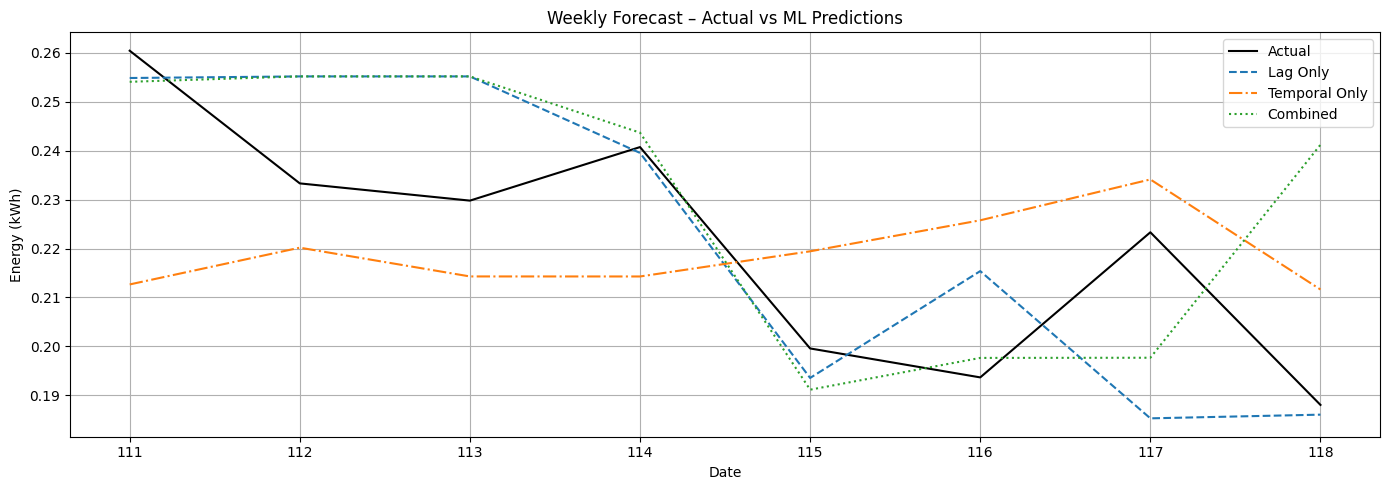

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(y_test_comb_w.index, y_test_comb_w.values, label='Actual', color='black')
plt.plot(y_test_lag_w.index, y_pred_lag_w, label='Lag Only', linestyle='--')
plt.plot(y_test_temp_w.index, y_pred_temp_w, label='Temporal Only', linestyle='-.')
plt.plot(y_test_comb_w.index, y_pred_comb_w, label='Combined', linestyle='dotted')

plt.title('Weekly Forecast – Actual vs ML Predictions')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
mae_lag_w = mean_absolute_error(y_test_lag_w, y_pred_lag_w)
rmse_lag_w = np.sqrt(mean_squared_error(y_test_lag_w, y_pred_lag_w))

mae_temp_w = mean_absolute_error(y_test_temp_w, y_pred_temp_w)
rmse_temp_w = np.sqrt(mean_squared_error(y_test_temp_w, y_pred_temp_w))

mae_comb_w = mean_absolute_error(y_test_comb_w, y_pred_comb_w)
rmse_comb_w = np.sqrt(mean_squared_error(y_test_comb_w, y_pred_comb_w))

print(f"[Weekly | Lag Only]      MAE: {mae_lag_w:.4f}, RMSE: {rmse_lag_w:.4f}")
print(f"[Weekly | Temporal Only] MAE: {mae_temp_w:.4f}, RMSE: {rmse_temp_w:.4f}")
print(f"[Weekly | Combined]      MAE: {mae_comb_w:.4f}, RMSE: {rmse_comb_w:.4f}")


[Weekly | Lag Only]      MAE: 0.0152, RMSE: 0.0197
[Weekly | Temporal Only] MAE: 0.0236, RMSE: 0.0262
[Weekly | Combined]      MAE: 0.0185, RMSE: 0.0243


In [26]:
df_monthly_lag = prepare_features(df_monthly, lags=[1, 2, 3], temporal=False, freq='M')
X_train_lag_m, X_test_lag_m, y_train_lag_m, y_test_lag_m = train_test_split(df_monthly_lag, test_size=3)

model_lag_m = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_lag_m.fit(X_train_lag_m, y_train_lag_m)
y_pred_lag_m = model_lag_m.predict(X_test_lag_m)


In [27]:
df_monthly_temp = prepare_features(df_monthly, lags=None, temporal=True, freq='M')
X_train_temp_m, X_test_temp_m, y_train_temp_m, y_test_temp_m = train_test_split(df_monthly_temp, test_size=3)

model_temp_m = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_temp_m.fit(X_train_temp_m, y_train_temp_m)
y_pred_temp_m = model_temp_m.predict(X_test_temp_m)


In [28]:
df_monthly_comb = prepare_features(df_monthly, lags=[1, 2, 3], temporal=True, freq='M')
X_train_comb_m, X_test_comb_m, y_train_comb_m, y_test_comb_m = train_test_split(df_monthly_comb, test_size=3)

model_comb_m = RandomForestRegressor(n_estimators=100, bootstrap=False, random_state=42)
model_comb_m.fit(X_train_comb_m, y_train_comb_m)
y_pred_comb_m = model_comb_m.predict(X_test_comb_m)


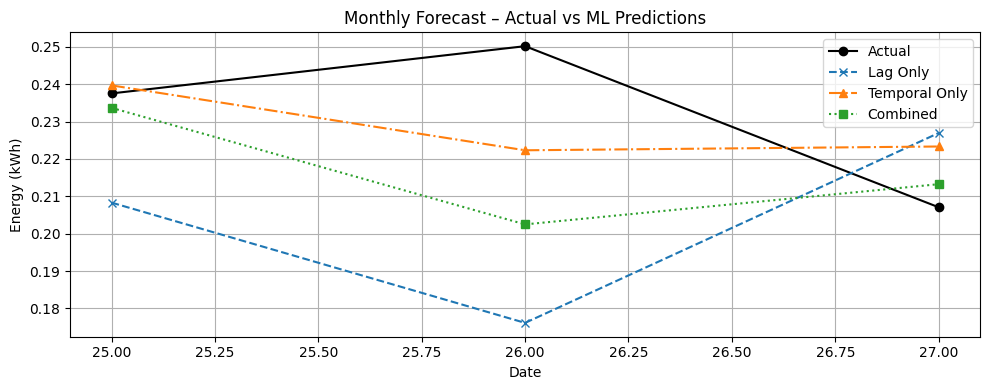

In [29]:
plt.figure(figsize=(10, 4))

plt.plot(y_test_comb_m.index, y_test_comb_m.values, label='Actual', color='black', marker='o')
plt.plot(y_test_lag_m.index, y_pred_lag_m, label='Lag Only', linestyle='--', marker='x')
plt.plot(y_test_temp_m.index, y_pred_temp_m, label='Temporal Only', linestyle='-.', marker='^')
plt.plot(y_test_comb_m.index, y_pred_comb_m, label='Combined', linestyle='dotted', marker='s')

plt.title('Monthly Forecast – Actual vs ML Predictions')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
mae_lag_m = mean_absolute_error(y_test_lag_m, y_pred_lag_m)
rmse_lag_m = np.sqrt(mean_squared_error(y_test_lag_m, y_pred_lag_m))

mae_temp_m = mean_absolute_error(y_test_temp_m, y_pred_temp_m)
rmse_temp_m = np.sqrt(mean_squared_error(y_test_temp_m, y_pred_temp_m))

mae_comb_m = mean_absolute_error(y_test_comb_m, y_pred_comb_m)
rmse_comb_m = np.sqrt(mean_squared_error(y_test_comb_m, y_pred_comb_m))

print(f"[Monthly | Lag Only]      MAE: {mae_lag_m:.4f}, RMSE: {rmse_lag_m:.4f}")
print(f"[Monthly | Temporal Only] MAE: {mae_temp_m:.4f}, RMSE: {rmse_temp_m:.4f}")
print(f"[Monthly | Combined]      MAE: {mae_comb_m:.4f}, RMSE: {rmse_comb_m:.4f}")


[Monthly | Lag Only]      MAE: 0.0411, RMSE: 0.0474
[Monthly | Temporal Only] MAE: 0.0154, RMSE: 0.0187
[Monthly | Combined]      MAE: 0.0192, RMSE: 0.0279


In [37]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
# Use daily + combined feature set
X_train_svr = X_train_comb_d
X_test_svr = X_test_comb_d
y_train_svr = y_train_comb_d
y_test_svr = y_test_comb_d

# Scale features
scaler = StandardScaler()
X_train_svr_scaled = scaler.fit_transform(X_train_svr)
X_test_svr_scaled = scaler.transform(X_test_svr)



In [ ]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_svr_scaled, y_train_svr)

y_pred_svr = svr_model.predict(X_test_svr_scaled)


In [39]:
mae_svr = mean_absolute_error(y_test_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_svr, y_pred_svr))

print(f"[Daily | Combined | SVR] MAE: {mae_svr:.4f}, RMSE: {rmse_svr:.4f}")


[Daily | Combined | SVR] MAE: 0.0504, RMSE: 0.0654


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
# Use same combined daily data
X_train_skgboost = X_train_comb_d
X_test_skgboost = X_test_comb_d
y_train_skgboost = y_train_comb_d
y_test_skgboost = y_test_comb_d

# Train model
skgboost_model = HistGradientBoostingRegressor(random_state=42)
skgboost_model.fit(X_train_skgboost, y_train_skgboost)

# Predict
y_pred_skgboost = skgboost_model.predict(X_test_skgboost)


In [41]:
mae_skgboost = mean_absolute_error(y_test_skgboost, y_pred_skgboost)
rmse_skgboost = np.sqrt(mean_squared_error(y_test_skgboost, y_pred_skgboost))

print(f"[Daily | Combined | HistGBR] MAE: {mae_skgboost:.4f}, RMSE: {rmse_skgboost:.4f}")


[Daily | Combined | HistGBR] MAE: 0.0480, RMSE: 0.0611


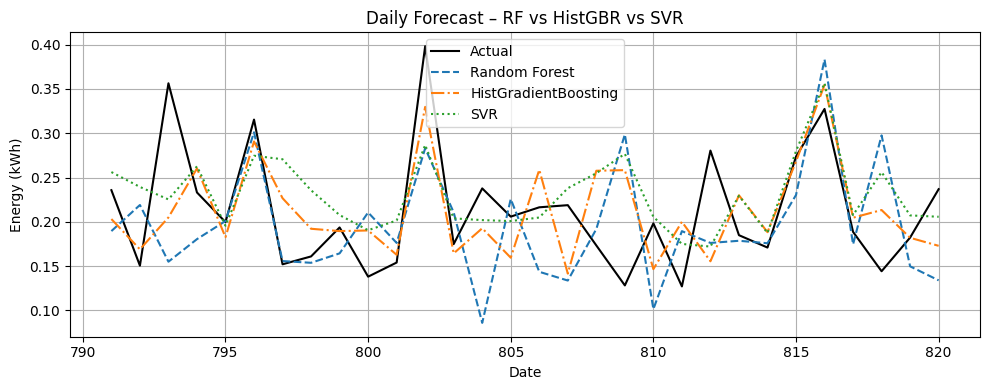

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_comb_d.index, y_test_comb_d.values, label='Actual', color='black')
plt.plot(y_test_comb_d.index, y_pred_comb_d, label='Random Forest', linestyle='--')
plt.plot(y_test_comb_d.index, y_pred_skgboost, label='HistGradientBoosting', linestyle='-.')
plt.plot(y_test_comb_d.index, y_pred_svr, label='SVR', linestyle='dotted')
plt.title('Daily Forecast – RF vs HistGBR vs SVR')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Final Notebook Summary: ML Forecasting for Energy Consumption

This notebook explored machine learning approaches to forecast energy consumption using time series data across multiple granularities. We focused on evaluating the effect of feature engineering techniques and compared several models.

---

### Objectives:

- Forecast energy at **hourly**, **daily**, **weekly**, and **monthly** resolutions
- Compare performance using:
  - **Time Delay Embedding** (lag features)
  - **Temporal Embedding** (e.g., hour, day, month)
  - **Combined Embedding**
- Train ML models without bootstrapping using:
  - Random Forest
  - Support Vector Regression (SVR)
  - HistGradientBoostingRegressor (XGB-like)

---

### Key Results:

| Resolution | Features | Model        | MAE    | RMSE   |
| ---------- | -------- | ------------ | ------ | ------ |
| Hourly     | Combined | RandomForest | 0.1159 | 0.2149 |
| Daily      | Combined | RandomForest | 0.0622 | 0.0819 |
| Daily      | Combined | HistGBR      | 0.0480 | 0.0611 |
| Daily      | Combined | SVR          | 0.0504 | 0.0654 |
| Weekly     | Combined | RandomForest | 0.0185 | 0.0243 |
| Monthly    | Combined | RandomForest | 0.0192 | 0.0279 |

---

### Insights:

- **Combined features didn't outperformed individual embeddings**.
- **Temporal-only features** can be surprisingly strong.
- **HistGradientBoosting** performed comparably to Random Forest even better.
- **SVR** showed good performance after scaling but show smoother output.

---

### Bonus Models:

- Implemented **HistGradientBoosting** from `sklearn.ensemble` as an XGBoost alternative.
- Implemented **SVR with scaling**, ideal for small, smooth datasets.

---

### Prompts Used in This Notebook:

- "Create time delay embedding and temporal embedding functions"
- "Train Random Forest without bootstrapping"
- "Plot forecast performance for hourly, daily, weekly and monthly"
- "Add and evaluate HistGradientBoosting from sklearn"
- "Try SVR as another model""
